In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
dataset_path = "/kaggle/input/datasets/bibihazaratunnesa/flower-species-dataset/Flower"

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2

2026-03-14 16:57:24.279130: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773507444.448033      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773507444.498055      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773507444.894375      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773507444.894416      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773507444.894419      55 computation_placer.cc:177] computation placer alr

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    dataset_path + "/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_data = test_gen.flow_from_directory(
    dataset_path + "/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 820 images belonging to 6 classes.
Found 212 images belonging to 6 classes.


In [5]:
cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(6,activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773507554.189690      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773507554.195701      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
cnn_history = cnn_model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1773507586.502624     148 service.cc:152] XLA service 0x7b3860005b00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773507586.502682     148 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773507586.502690     148 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773507586.912427     148 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-14 16:59:49.455561: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 16:59:49.603507: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 2/26 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.2266 - loss: 3.4737

I0000 00:00:1773507592.785350     148 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14/26 ━━━━━━━━━━━━━━━━━━━━ 9s 789ms/step - accuracy: 0.1976 - loss: 3.1506 

2026-03-14 17:00:05.067746: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:00:05.213268: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


26/26 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.2226 - loss: 2.6920 - val_accuracy: 0.4245 - val_loss: 1.4358
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 779ms/step - accuracy: 0.4275 - loss: 1.4274 - val_accuracy: 0.4906 - val_loss: 1.3042
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 779ms/step - accuracy: 0.5117 - loss: 1.2624 - val_accuracy: 0.5000 - val_loss: 1.3487
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 786ms/step - accuracy: 0.5756 - loss: 1.1981 - val_accuracy: 0.5094 - val_loss: 1.2457
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 787ms/step - accuracy: 0.5876 - loss: 1.1005 - val_accuracy: 0.5472 - val_loss: 1.2332
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 781ms/step - accuracy: 0.6089 - loss: 1.0652 - val_accuracy: 0.5802 - val_loss: 1.2017
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 782ms/step - accuracy: 0.6052 - loss: 1.0180 - val_accuracy: 0.5708 - val_loss: 1.1618
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 779ms/step - accuracy: 0.6323 - loss: 1.0099 - val_accuracy: 0.5755 -

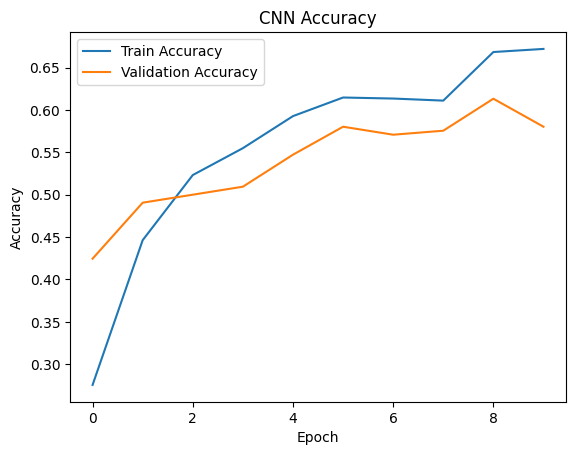

In [7]:
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

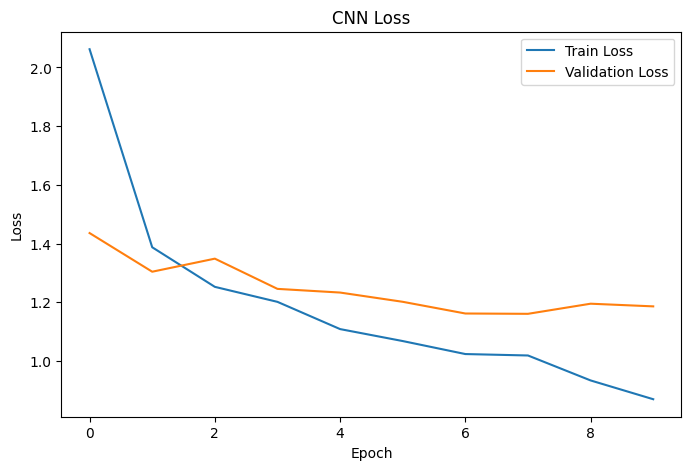

In [8]:
plt.figure(figsize=(8,5))

plt.plot(cnn_history.history['loss'], label='Train Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [9]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [11]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(6, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=predictions)

In [14]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
mobilenet_history = mobilenet_model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10


2026-03-14 17:11:55.635415: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:11:55.771474: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


15/26 ━━━━━━━━━━━━━━━━━━━━ 7s 670ms/step - accuracy: 0.2686 - loss: 1.9620

2026-03-14 17:12:15.949679: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 17:12:16.090307: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


26/26 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.3455 - loss: 1.7512 - val_accuracy: 0.7075 - val_loss: 0.8665
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 799ms/step - accuracy: 0.7034 - loss: 0.8300 - val_accuracy: 0.7406 - val_loss: 0.6872
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 776ms/step - accuracy: 0.7702 - loss: 0.6227 - val_accuracy: 0.7925 - val_loss: 0.5986
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 778ms/step - accuracy: 0.8574 - loss: 0.4687 - val_accuracy: 0.7830 - val_loss: 0.5229
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 791ms/step - accuracy: 0.8435 - loss: 0.4518 - val_accuracy: 0.8019 - val_loss: 0.5481
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 789ms/step - accuracy: 0.8478 - loss: 0.4113 - val_accuracy: 0.8160 - val_loss: 0.5079
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 787ms/step - accuracy: 0.8960 - loss: 0.3073 - val_accuracy: 0.8585 - val_loss: 0.4456
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 784ms/step - accuracy: 0.8972 - loss: 0.3123 - val_accuracy: 0.8491 -

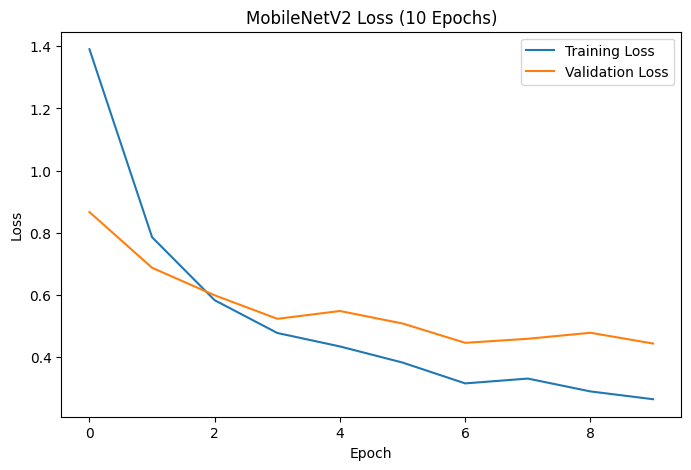

In [19]:
plt.figure(figsize=(8,5))

plt.plot(mobilenet_history.history['loss'], label='Training Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')

plt.title("MobileNetV2 Loss (10 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

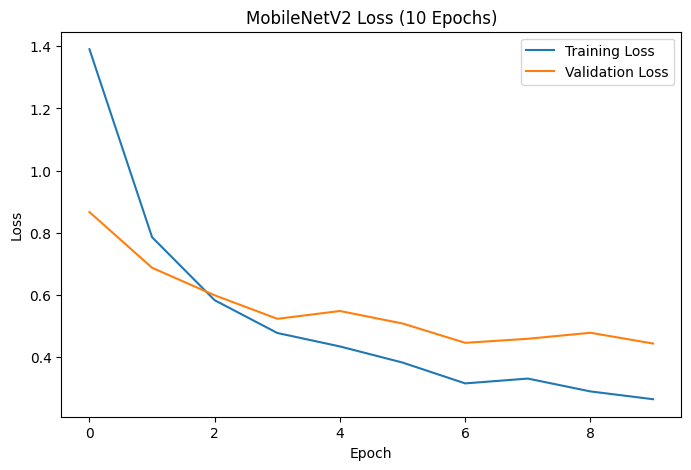

In [18]:
plt.figure(figsize=(8,5))

plt.plot(mobilenet_history.history['loss'], label='Training Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Validation Loss')

plt.title("MobileNetV2 Loss (10 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

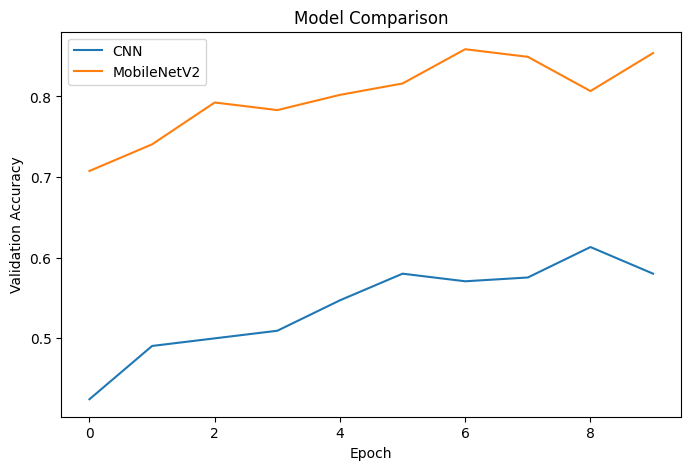

In [20]:
plt.figure(figsize=(8,5))

plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(mobilenet_history.history['val_accuracy'], label='MobileNetV2')

plt.title("Model Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

In [24]:
y_pred = mobilenet_model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_data.classes
class_labels = list(test_data.class_indices.keys())

7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 999ms/step


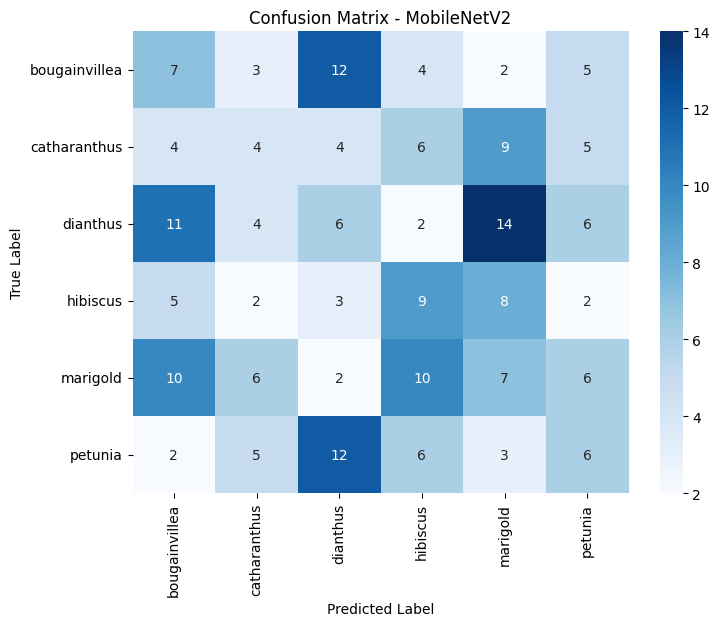

In [25]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - MobileNetV2")

plt.show()

In [26]:
y_pred_cnn = cnn_model.predict(test_data)
y_pred_cnn_classes = np.argmax(y_pred_cnn, axis=1)

y_true = test_data.classes
class_labels = list(test_data.class_indices.keys())

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 359ms/step


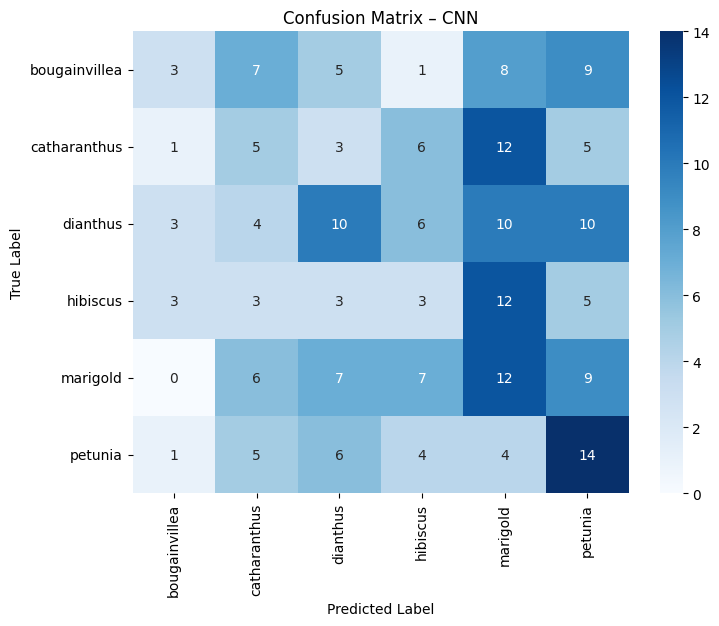

In [28]:
cm_cnn = confusion_matrix(y_true, y_pred_cnn_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm_cnn,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – CNN")

plt.show()

In [30]:
from tensorflow.keras.preprocessing import image

In [41]:
img_path = "/kaggle/input/datasets/bibihazaratunnesa/flower-species-dataset/Flower/test/hibiscus/h119.jpeg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [42]:
prediction = mobilenet_model.predict(img_array)

predicted_class = class_labels[np.argmax(prediction)]

print("Predicted Flower:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted Flower: hibiscus


In [43]:
prediction = mobilenet_model.predict(img_array)

predicted_class = class_labels[np.argmax(prediction)]

print("Predicted Flower:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Flower: hibiscus
